In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

signal.shape=(650000,)


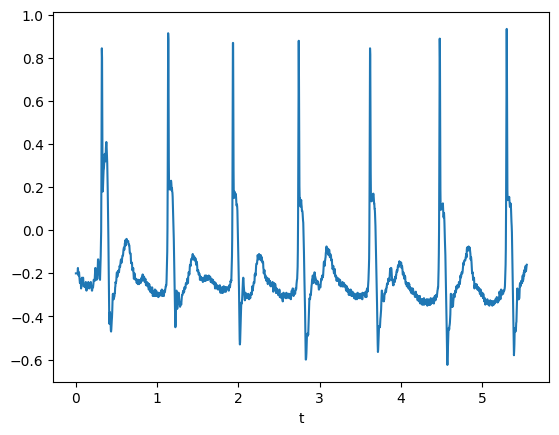

In [61]:
signal = pd.read_csv("data/102_V5.dat", header=None)
signal = signal.to_numpy().flatten()

print(f"{signal.shape=}")

fs = 360

plt.plot(np.arange(2000) / fs, signal[:2000])
plt.xlabel("t")
plt.show()

In [62]:
signal[:100]

array([-0.2  , -0.2  , -0.2  , -0.2  , -0.2  , -0.2  , -0.2  , -0.2  ,
       -0.19 , -0.175, -0.19 , -0.205, -0.21 , -0.2  , -0.195, -0.21 ,
       -0.23 , -0.235, -0.245, -0.235, -0.23 , -0.23 , -0.245, -0.27 ,
       -0.26 , -0.24 , -0.225, -0.22 , -0.225, -0.225, -0.225, -0.225,
       -0.22 , -0.235, -0.26 , -0.26 , -0.26 , -0.26 , -0.255, -0.255,
       -0.26 , -0.26 , -0.265, -0.25 , -0.24 , -0.255, -0.265, -0.28 ,
       -0.26 , -0.255, -0.25 , -0.245, -0.25 , -0.255, -0.245, -0.24 ,
       -0.25 , -0.245, -0.265, -0.27 , -0.25 , -0.25 , -0.245, -0.25 ,
       -0.255, -0.255, -0.24 , -0.245, -0.265, -0.26 , -0.27 , -0.28 ,
       -0.28 , -0.265, -0.265, -0.26 , -0.265, -0.255, -0.245, -0.23 ,
       -0.23 , -0.235, -0.23 , -0.235, -0.215, -0.19 , -0.175, -0.175,
       -0.195, -0.225, -0.225, -0.225, -0.23 , -0.215, -0.225, -0.225,
       -0.205, -0.165, -0.135, -0.135])

In [63]:
with open("data/102_attr.dat") as f:
    content = f.read()
    lines = content.split("\n")
    import re

    numbers = [int(n) for n in re.findall(r"\d+", content)]

GT_PEAKS = np.array(numbers)
GT_PEAKS.shape

(2187,)

In [64]:
def create_hamming(N):
    n = np.arange(N)
    hamming = 0.54 - 0.46 * np.cos(2 * np.pi * n / (N - 1))
    return hamming

Text(0.5, 1.0, 'hamming window')

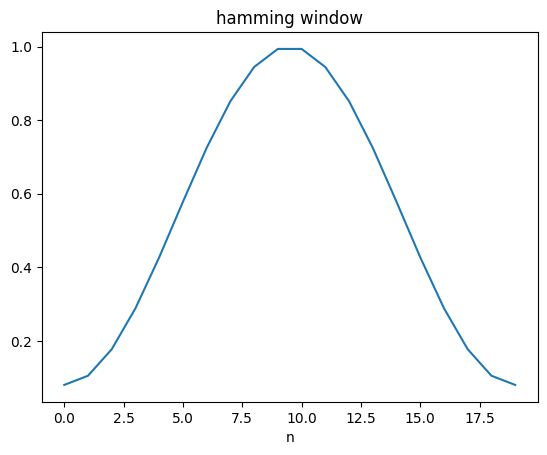

In [65]:
hamming = create_hamming(20)

plt.plot(range(20), hamming)
plt.xlabel("n")
plt.title("hamming window")

In [66]:
M = 20

Text(0.5, 1.0, 'lowpass')

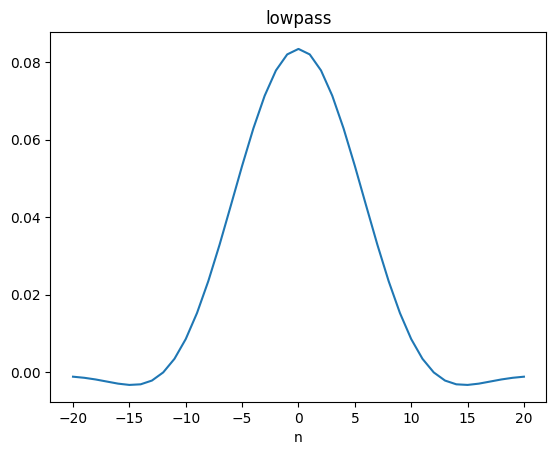

In [67]:
fc = 15
fc_hat = fc / fs
lowpass = np.zeros(2*M + 1)

for i in range(2*M + 1):
    n = i - M
    if n == 0:
        lowpass[i] = 2 * fc_hat
    else:
        lowpass[i] = np.sin(2*np.pi*fc_hat*n) / (np.pi * n)

lowpass *= create_hamming(2*M + 1)

plt.plot(range(-M, M+1), lowpass)
plt.xlabel("n")
plt.title("lowpass")

Text(0.5, 1.0, 'highpass')

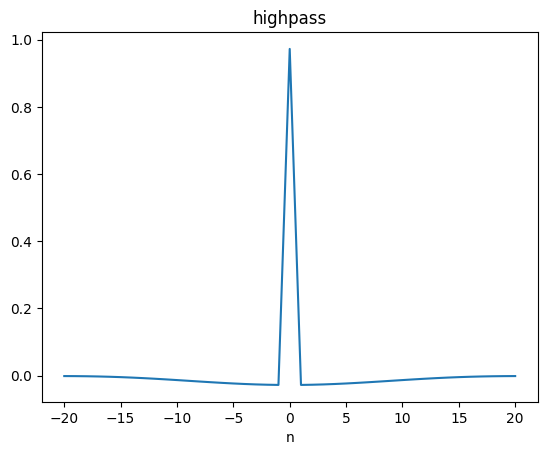

In [68]:
fc = 5
fc_hat = fc / fs
highpass = np.zeros(2*M + 1)

for i in range(2*M + 1):
    n = i - M
    if n == 0:
        highpass[i] = 1 - 2*fc_hat
    else:
        highpass[i] = -np.sin(2*np.pi*fc_hat*n) / (np.pi * n)

highpass *= create_hamming(2*M + 1)

plt.plot(range(-M, M+1), highpass)
plt.xlabel("n")
plt.title("highpass")

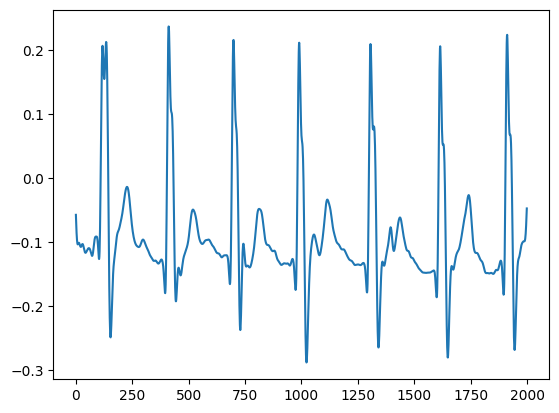

In [69]:
fragment = signal[:2000]
# fragment = signal
gt_fragment_peaks = GT_PEAKS[GT_PEAKS < fragment.shape[0]]

fragment = np.convolve(fragment, lowpass, mode="same")
fragment = np.convolve(fragment, highpass, mode="same")

plt.plot(fragment)

In [70]:
def differentiate(x):
    kernel = -np.array([-1, -2, 0, 2, 1]) / 8.0
    return np.convolve(x, kernel, mode="same")

def integrate(x, C):
    return np.convolve(x, np.ones(C), mode="same") / C

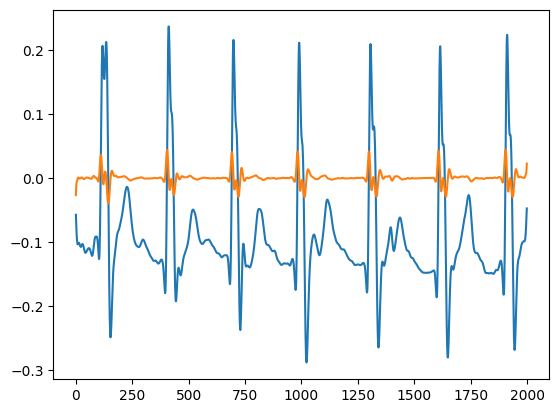

In [71]:
diff = differentiate(fragment)

plt.plot(fragment)
plt.plot(diff)

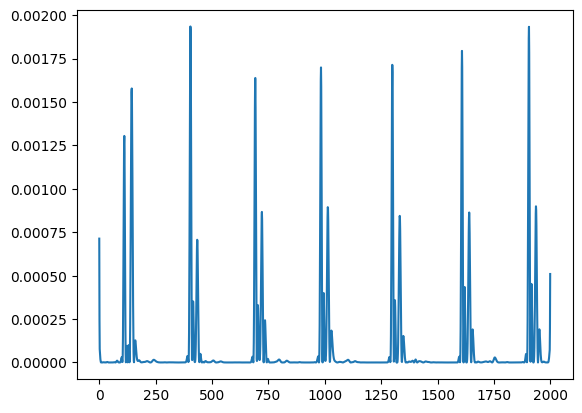

In [72]:
squared = diff**2
plt.plot(squared)

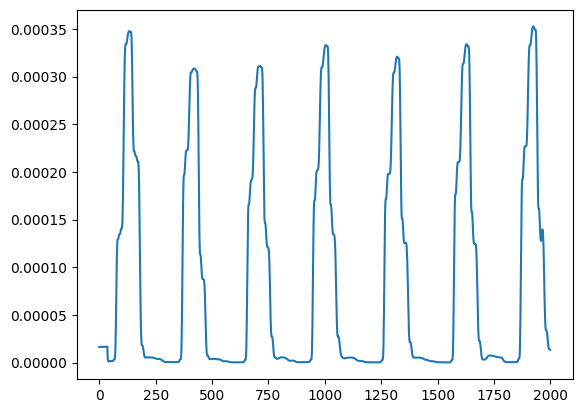

In [73]:
C = int(0.20 * fs)
integrated = integrate(squared, C)
plt.plot(integrated)

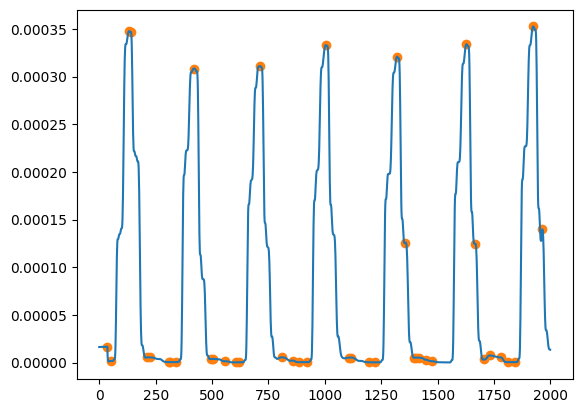

In [74]:
diff_integrated = differentiate(integrated)
zero_crossings = np.where((diff_integrated[:-1] > 0) & (diff_integrated[1:] < 0))[0]
plt.plot(integrated)
plt.scatter(zero_crossings, integrated[zero_crossings], color="tab:orange")

THRESHOLD_I1=3.955137526837717e-05, THRESHOLD_I2=1.9775687634188586e-05


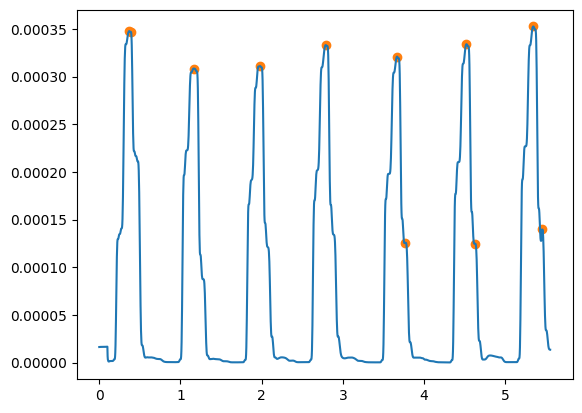

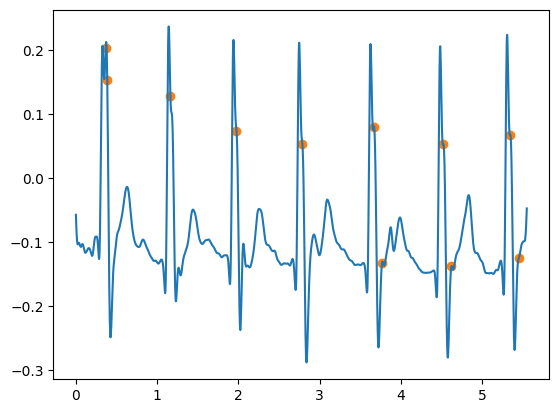

In [75]:
# Inicjalizacja progów na podstawie pierwszych sekund scałkowanego sygnału
init_chunk = integrated[: min(len(integrated), fs * 2)]
SPKI = np.max(init_chunk) * 0.35 if len(init_chunk) > 0 else 0.1
NPKI = SPKI * 0.1
THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
THRESHOLD_I2 = 0.5 * THRESHOLD_I1
print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")

integrated_peaks = []
for peak_i in zero_crossings:
    value = integrated[peak_i]
    if value >= THRESHOLD_I1:
        # Signal peak
        SPKI = 0.125 * value + 0.875 * SPKI
        # print(f"{SPKI=}")
        integrated_peaks.append(peak_i)

        THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
        THRESHOLD_I2 = 0.5 * THRESHOLD_I1
        # print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")
    elif value >= THRESHOLD_I2:
        # Noise peak
        NPKI = 0.125 * value + 0.875 * NPKI
        # print(f"{NPKI=}")

        THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
        THRESHOLD_I2 = 0.5 * THRESHOLD_I1
        # print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")

integrated_peaks = np.array(integrated_peaks, dtype=int)
plt.subplot()
plt.plot(np.arange(len(integrated))/fs, integrated)
plt.scatter(integrated_peaks/fs, integrated[integrated_peaks], color="tab:orange")
plt.show()

plt.subplot()
plt.plot(np.arange(len(fragment))/fs, fragment)
plt.scatter(integrated_peaks/fs, fragment[integrated_peaks], color="tab:orange")
plt.show()

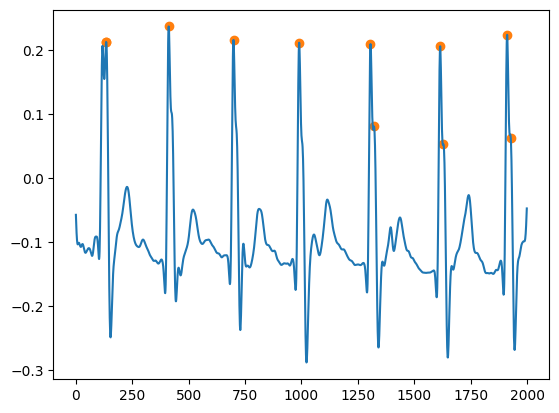

In [76]:
signal_peaks = []
search_window = int(0.1 * fs)

for peak in integrated_peaks:
    left = max(0, peak - search_window)
    right = min(len(fragment), peak + search_window)
    real_r = left + np.argmax(fragment[left:right])
    signal_peaks.append(real_r)

signal_peaks = np.array(signal_peaks, dtype=int)

# offset = -10
# signal_peaks = np.clip(integrated_peaks + offset, 0, fragment.shape[0]-1)

plt.plot(fragment)
plt.scatter(signal_peaks, fragment[signal_peaks], color="tab:orange")

In [77]:
MIN_DISTANCE_S = 0.2
MIN_DISTANCE_INDICES = fs * MIN_DISTANCE_S
print(f"{MIN_DISTANCE_INDICES=}")
too_close_peaks = np.where(signal_peaks[1:] - signal_peaks[:-1] < MIN_DISTANCE_INDICES)[0] + 1
while too_close_peaks.shape[0] > 0:
    signal_peaks = np.delete(signal_peaks, too_close_peaks[0])
    too_close_peaks = np.where(signal_peaks[1:] - signal_peaks[:-1] < MIN_DISTANCE_INDICES)[0] + 1

signal_peaks

MIN_DISTANCE_INDICES=72.0


array([ 134,  411,  699,  990, 1306, 1615, 1912])

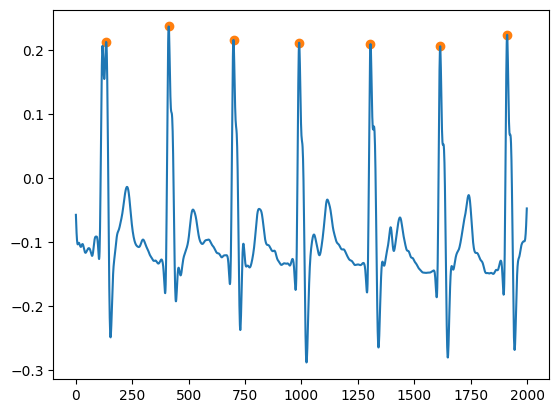

In [78]:
plt.plot(fragment)
plt.scatter(signal_peaks, fragment[signal_peaks], color="tab:orange")

In [79]:
def evaluate_detections(signal_peaks, gt_peaks):
    tolerance_samples_ms = 30
    tolerance_samples = int(fs * (tolerance_samples_ms / 1000.))
    print(f"{tolerance_samples=}")

    unmatched_detected = list(signal_peaks)

    tp_errors_samples = []
    matched_gt = []
    matched_det = []

    for gt in gt_peaks:
        if len(unmatched_detected) == 0:
            break

        distances = np.abs(np.array(unmatched_detected) - gt)
        min_idx = np.argmin(distances)
        min_dist = distances[min_idx]

        if min_dist <= tolerance_samples:
            closest_det = unmatched_detected.pop(min_idx)

            tp_errors_samples.append(closest_det - gt)
            matched_gt.append(gt)
            matched_det.append(closest_det)

    TP = len(tp_errors_samples)

    FN = len(gt_peaks) - TP

    FP = len(signal_peaks) - TP

    errors_ms = (np.array(tp_errors_samples) / fs) * 1000.0

    if TP > 0:
        mae = np.mean(np.abs(errors_ms))
        sd = np.std(errors_ms)
    else:
        mae, sd = 0.0, 0.0

    metrics = {
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "agreement": TP / (TP + FN + FP),
        "MAE_ms": mae,
        "SD_ms": sd,
        "errors_ms": errors_ms,
        "matched_gt": np.array(matched_gt),
        "matched_det": np.array(matched_det),
    }

    return metrics

In [80]:
signal_peaks

array([ 134,  411,  699,  990, 1306, 1615, 1912])

In [81]:
gt_fragment_peaks

array([ 136,  410,  697,  989, 1305, 1614, 1911])

In [82]:
evaluate_detections(signal_peaks, gt_fragment_peaks)

tolerance_samples=10


{'TP': 7,
 'FP': 0,
 'FN': 0,
 'agreement': 1.0,
 'MAE_ms': 3.5714285714285716,
 'SD_ms': 3.223824763744429,
 'errors_ms': array([-5.55555556,  2.77777778,  5.55555556,  2.77777778,  2.77777778,
         2.77777778,  2.77777778]),
 'matched_gt': array([ 136,  410,  697,  989, 1305, 1614, 1911]),
 'matched_det': array([ 134,  411,  699,  990, 1306, 1615, 1912])}

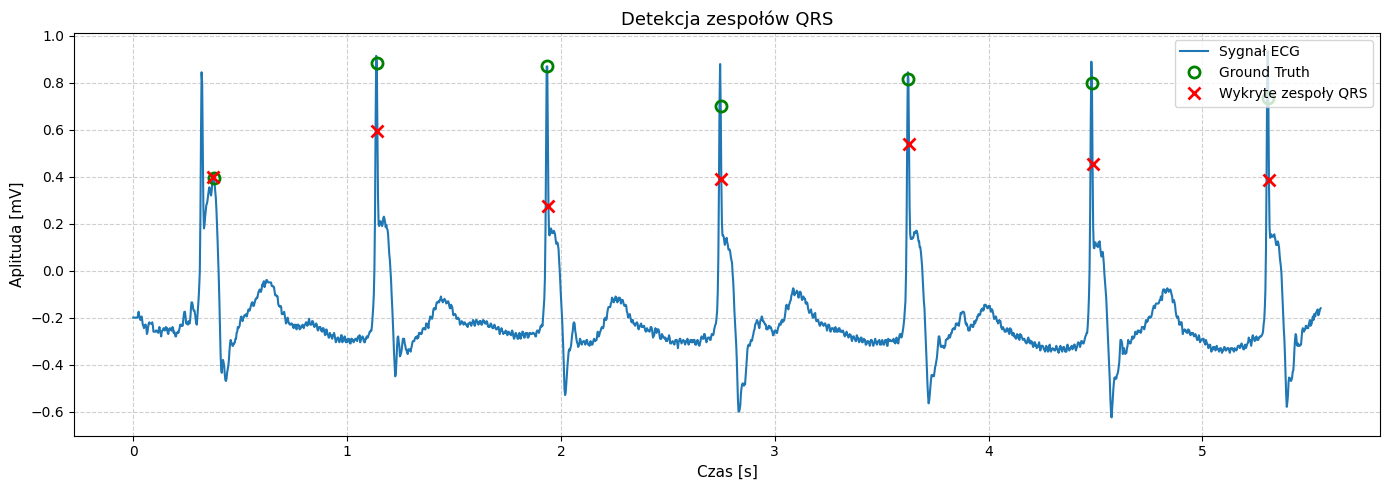

In [83]:
import matplotlib.pyplot as plt
import numpy as np

start_sample = 0
end_sample = 2000

ecg_fragment = signal[start_sample:end_sample]
time_axis = (
        np.arange(start_sample, end_sample) / fs
)

detected_in_fragment = signal_peaks[(signal_peaks >= start_sample) & (signal_peaks < end_sample)]
gt_in_fragment = gt_fragment_peaks[(gt_fragment_peaks >= start_sample) & (gt_fragment_peaks < end_sample)]

plt.figure(figsize=(14, 5))

plt.plot(time_axis, ecg_fragment, label="Sygnał ECG")

plt.plot(
    gt_in_fragment / fs,
    signal[gt_in_fragment],
    "go",
    markersize=8,
    markerfacecolor="none",
    markeredgewidth=2,
    label="Ground Truth",
)

plt.plot(
    detected_in_fragment / fs,
    signal[detected_in_fragment],
    "rx",
    markersize=9,
    markeredgewidth=2,
    label="Wykryte zespoły QRS",
)

plt.title("Detekcja zespołów QRS", fontsize=13)
plt.xlabel("Czas [s]", fontsize=11)
plt.ylabel("Aplituda [mV]", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()

In [84]:
# Above code combined in one function for testing
def detect_r_peaks(ecg, fs, integration_window):
    def create_lowpass(M, fs):
        fc = 15
        fc_hat = fc / fs
        lowpass = np.zeros(2*M + 1)

        for i in range(2*M + 1):
            n = i - M
            if n == 0:
                lowpass[i] = 2 * fc_hat
            else:
                lowpass[i] = np.sin(2*np.pi*fc_hat*n) / (np.pi * n)

        lowpass *= create_hamming(2*M + 1)
        return lowpass

    def create_highpass(M, fs):
        fc = 5
        fc_hat = fc / fs
        highpass = np.zeros(2*M + 1)

        for i in range(2*M + 1):
            n = i - M
            if n == 0:
                highpass[i] = 1 - 2*fc_hat
            else:
                highpass[i] = -np.sin(2*np.pi*fc_hat*n) / (np.pi * n)

        highpass *= create_hamming(2*M + 1)
        return highpass

    M = 20

    signal = np.convolve(ecg, create_lowpass(M, fs), mode="same")
    signal = np.convolve(signal, create_highpass(M, fs), mode="same")

    diff = differentiate(signal)

    squared = diff**2

    C = integration_window
    integrated = integrate(squared, C)

    diff_integrated = differentiate(integrated)
    zero_crossings = np.where((diff_integrated[:-1] > 0) & (diff_integrated[1:] < 0))[0]

    # Inicjalizacja progów na podstawie pierwszych sekund scałkowanego sygnału
    init_chunk = integrated[: min(len(integrated), fs * 2)]
    SPKI = np.max(init_chunk) * 0.35 if len(init_chunk) > 0 else 0.1
    NPKI = SPKI * 0.1
    THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
    THRESHOLD_I2 = 0.5 * THRESHOLD_I1
    print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")

    integrated_peaks = []
    for peak_i in zero_crossings:
        value = integrated[peak_i]
        if value >= THRESHOLD_I1:
            # Signal peak
            SPKI = 0.125 * value + 0.875 * SPKI
            # print(f"{SPKI=}")
            integrated_peaks.append(peak_i)

            THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
            THRESHOLD_I2 = 0.5 * THRESHOLD_I1
            # print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")
        elif value >= THRESHOLD_I2:
            # Noise peak
            NPKI = 0.125 * value + 0.875 * NPKI
            # print(f"{NPKI=}")

            THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
            THRESHOLD_I2 = 0.5 * THRESHOLD_I1
            # print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")

    integrated_peaks = np.array(integrated_peaks, dtype=int)

    signal_peaks = []
    search_window = int(0.1 * fs)

    for peak in integrated_peaks:
        left = max(0, peak - search_window)
        right = min(len(signal), peak + search_window)
        real_r = left + np.argmax(ecg[left:right])
        signal_peaks.append(real_r)

    signal_peaks = np.array(signal_peaks, dtype=int)

    MIN_DISTANCE_S = 0.2
    MIN_DISTANCE_INDICES = fs * MIN_DISTANCE_S
    print(f"{MIN_DISTANCE_INDICES=}")
    if len(signal_peaks) > 0:
        cleaned_peaks = [signal_peaks[0]]
        for p in signal_peaks[1:]:
            if p - cleaned_peaks[-1] >= MIN_DISTANCE_INDICES:
                cleaned_peaks.append(p)
        signal_peaks = np.array(cleaned_peaks, dtype=int)

    return signal_peaks


In [92]:
def detect_integrated_peaks(integrated):
    init_chunk = integrated[: min(len(integrated), fs * 2)]
    SPKI = np.max(init_chunk) * 0.35 if len(init_chunk) > 0 else 0.1
    NPKI = SPKI * 0.1
    THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
    THRESHOLD_I2 = 0.5 * THRESHOLD_I1
    print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")

    integrated_peaks = []
    for peak_i in zero_crossings:
        value = integrated[peak_i]
        if value >= THRESHOLD_I1:
            # Signal peak
            SPKI = 0.125 * value + 0.875 * SPKI
            # print(f"{SPKI=}")
            integrated_peaks.append(peak_i)

            THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
            THRESHOLD_I2 = 0.5 * THRESHOLD_I1
            # print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")
        elif value >= THRESHOLD_I2:
            # Noise peak
            NPKI = 0.125 * value + 0.875 * NPKI
            # print(f"{NPKI=}")

            THRESHOLD_I1 = NPKI + 0.25 * (SPKI-NPKI)
            THRESHOLD_I2 = 0.5 * THRESHOLD_I1
            # print(f"{THRESHOLD_I1=}, {THRESHOLD_I2=}")

    integrated_peaks = np.array(integrated_peaks, dtype=int)
    return integrated_peaks

THRESHOLD_I1=6.417317877625367e-05, THRESHOLD_I2=3.2086589388126836e-05


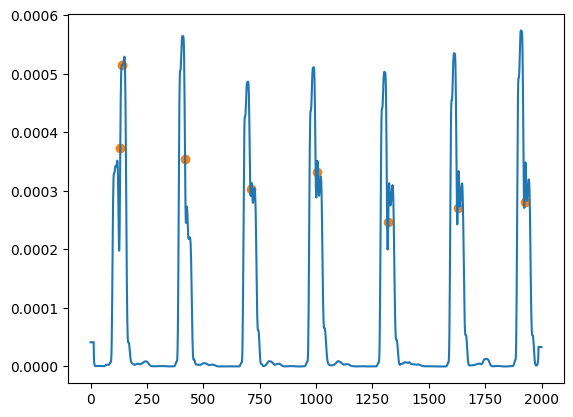

THRESHOLD_I1=1.6992753558353713e-05, THRESHOLD_I2=8.496376779176856e-06
MIN_DISTANCE_INDICES=72.0
tolerance_samples=10


{'TP': 7,
 'FP': 0,
 'FN': 0,
 'agreement': 1.0,
 'MAE_ms': 3.5714285714285716,
 'SD_ms': 3.223824763744429,
 'errors_ms': array([-5.55555556,  2.77777778,  5.55555556,  2.77777778,  2.77777778,
         2.77777778,  2.77777778]),
 'matched_gt': array([ 136,  410,  697,  989, 1305, 1614, 1911]),
 'matched_det': array([ 134,  411,  699,  990, 1306, 1615, 1912])}

In [95]:
C = int(0.08 * fs)
integrated = integrate(squared, C)
integrated_peaks = detect_integrated_peaks(integrated)
plt.plot(integrated)
plt.scatter(integrated_peaks, integrated[integrated_peaks], color="tab:orange")
plt.show()

p1 = detect_r_peaks(fragment, fs, C)
evaluate_detections(p1, gt_fragment_peaks)

THRESHOLD_I1=5.0832472806750935e-05, THRESHOLD_I2=2.5416236403375468e-05


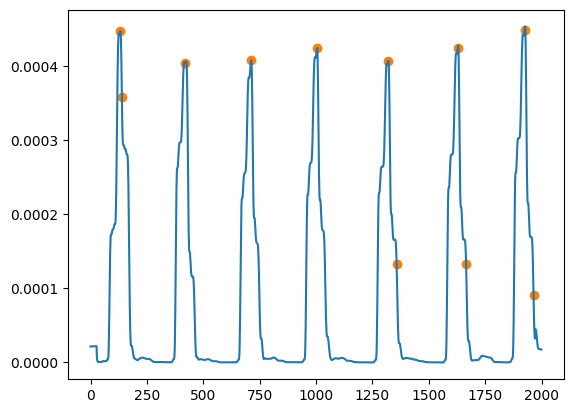

THRESHOLD_I1=1.268203649863633e-05, THRESHOLD_I2=6.341018249318165e-06
MIN_DISTANCE_INDICES=72.0
tolerance_samples=10


{'TP': 7,
 'FP': 0,
 'FN': 0,
 'agreement': 1.0,
 'MAE_ms': 3.5714285714285716,
 'SD_ms': 3.223824763744429,
 'errors_ms': array([-5.55555556,  2.77777778,  5.55555556,  2.77777778,  2.77777778,
         2.77777778,  2.77777778]),
 'matched_gt': array([ 136,  410,  697,  989, 1305, 1614, 1911]),
 'matched_det': array([ 134,  411,  699,  990, 1306, 1615, 1912])}

In [96]:
C = int(0.15 * fs)
integrated = integrate(squared, C)
integrated_peaks = detect_integrated_peaks(integrated)
plt.plot(integrated)
plt.scatter(integrated_peaks, integrated[integrated_peaks], color="tab:orange")
plt.show()

p1 = detect_r_peaks(fragment, fs, C)
evaluate_detections(p1, gt_fragment_peaks)

THRESHOLD_I1=3.955137526837717e-05, THRESHOLD_I2=1.9775687634188586e-05


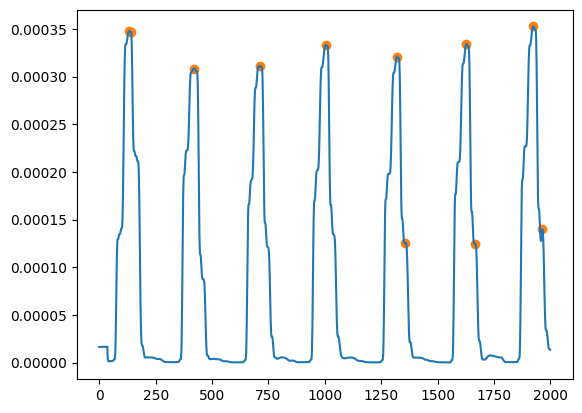

THRESHOLD_I1=1.0238069408799394e-05, THRESHOLD_I2=5.119034704399697e-06
MIN_DISTANCE_INDICES=72.0
tolerance_samples=10


{'TP': 7,
 'FP': 0,
 'FN': 0,
 'agreement': 1.0,
 'MAE_ms': 3.5714285714285716,
 'SD_ms': 3.223824763744429,
 'errors_ms': array([-5.55555556,  2.77777778,  5.55555556,  2.77777778,  2.77777778,
         2.77777778,  2.77777778]),
 'matched_gt': array([ 136,  410,  697,  989, 1305, 1614, 1911]),
 'matched_det': array([ 134,  411,  699,  990, 1306, 1615, 1912])}

In [101]:
C = int(0.20 * fs)
integrated = integrate(squared, C)
integrated_peaks = detect_integrated_peaks(integrated)
plt.plot(integrated)
plt.scatter(integrated_peaks, integrated[integrated_peaks], color="tab:orange")
plt.show()

p1 = detect_r_peaks(fragment, fs, C)
evaluate_detections(p1, gt_fragment_peaks)

THRESHOLD_I1=3.1839088884358605e-05, THRESHOLD_I2=1.5919544442179302e-05


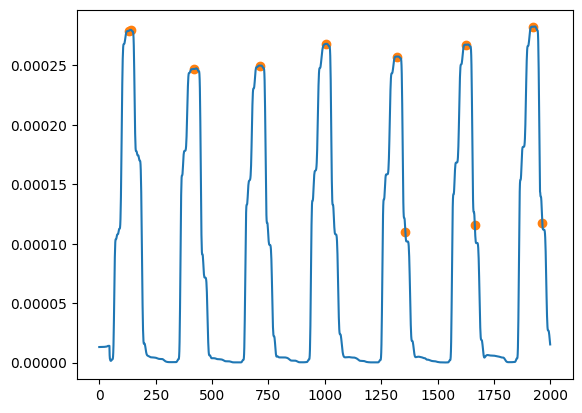

THRESHOLD_I1=8.289738663371412e-06, THRESHOLD_I2=4.144869331685706e-06
MIN_DISTANCE_INDICES=72.0
tolerance_samples=10


{'TP': 7,
 'FP': 0,
 'FN': 0,
 'agreement': 1.0,
 'MAE_ms': 3.5714285714285716,
 'SD_ms': 3.223824763744429,
 'errors_ms': array([-5.55555556,  2.77777778,  5.55555556,  2.77777778,  2.77777778,
         2.77777778,  2.77777778]),
 'matched_gt': array([ 136,  410,  697,  989, 1305, 1614, 1911]),
 'matched_det': array([ 134,  411,  699,  990, 1306, 1615, 1912])}

In [97]:
C = int(0.25 * fs)
integrated = integrate(squared, C)
integrated_peaks = detect_integrated_peaks(integrated)
plt.plot(integrated)
plt.scatter(integrated_peaks, integrated[integrated_peaks], color="tab:orange")
plt.show()

p1 = detect_r_peaks(fragment, fs, C)
evaluate_detections(p1, gt_fragment_peaks)

THRESHOLD_I1=2.6604189810317073e-05, THRESHOLD_I2=1.3302094905158536e-05


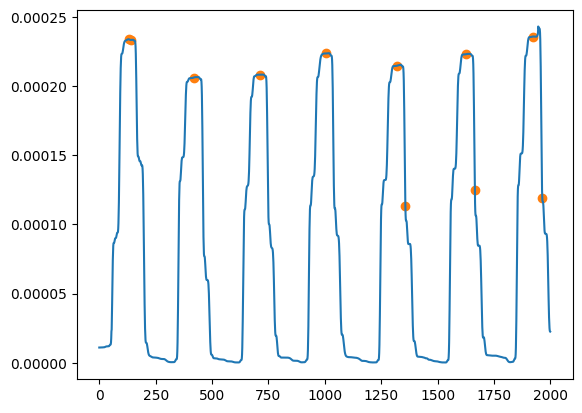

THRESHOLD_I1=6.9340139096644325e-06, THRESHOLD_I2=3.4670069548322163e-06
MIN_DISTANCE_INDICES=72.0
tolerance_samples=10


{'TP': 7,
 'FP': 1,
 'FN': 0,
 'agreement': 0.875,
 'MAE_ms': 3.5714285714285716,
 'SD_ms': 3.223824763744429,
 'errors_ms': array([-5.55555556,  2.77777778,  5.55555556,  2.77777778,  2.77777778,
         2.77777778,  2.77777778]),
 'matched_gt': array([ 136,  410,  697,  989, 1305, 1614, 1911]),
 'matched_det': array([ 134,  411,  699,  990, 1306, 1615, 1912])}

In [102]:
C = int(0.30 * fs)
integrated = integrate(squared, C)
integrated_peaks = detect_integrated_peaks(integrated)
plt.plot(integrated)
plt.scatter(integrated_peaks, integrated[integrated_peaks], color="tab:orange")
plt.show()

p1 = detect_r_peaks(fragment, fs, C)
evaluate_detections(p1, gt_fragment_peaks)

THRESHOLD_I1=2.0068910259656264e-05, THRESHOLD_I2=1.0034455129828132e-05


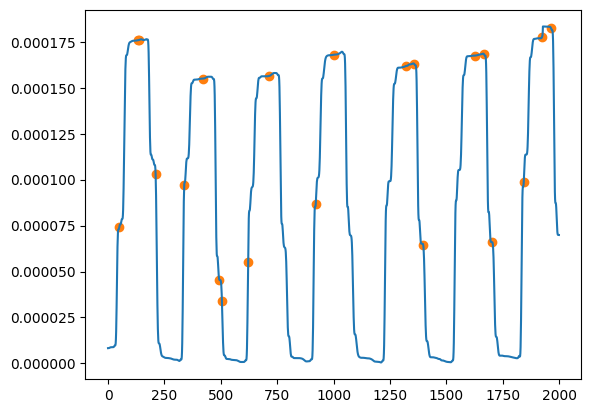

THRESHOLD_I1=5.225442969395215e-06, THRESHOLD_I2=2.6127214846976074e-06
MIN_DISTANCE_INDICES=72.0
tolerance_samples=10


{'TP': 7,
 'FP': 0,
 'FN': 0,
 'agreement': 1.0,
 'MAE_ms': 9.523809523809522,
 'SD_ms': 10.43884637933802,
 'errors_ms': array([-5.55555556,  2.77777778,  5.55555556, 25.        ,  2.77777778,
        22.22222222,  2.77777778]),
 'matched_gt': array([ 136,  410,  697,  989, 1305, 1614, 1911]),
 'matched_det': array([ 134,  411,  699,  998, 1306, 1622, 1912])}

In [98]:
C = int(0.40 * fs)
integrated = integrate(squared, C)
integrated_peaks = detect_integrated_peaks(integrated)
plt.plot(integrated)
plt.scatter(integrated_peaks, integrated[integrated_peaks], color="tab:orange")
plt.show()

p1 = detect_r_peaks(fragment, fs, C)
evaluate_detections(p1, gt_fragment_peaks)

THRESHOLD_I1=1.2939996447089987e-05, THRESHOLD_I2=6.469998223544994e-06


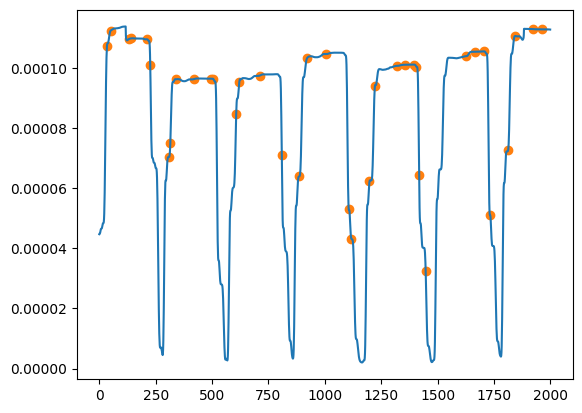

THRESHOLD_I1=3.352233617544208e-06, THRESHOLD_I2=1.676116808772104e-06
MIN_DISTANCE_INDICES=72.0
tolerance_samples=10


{'TP': 5,
 'FP': 12,
 'FN': 2,
 'agreement': 0.2631578947368421,
 'MAE_ms': 3.8888888888888884,
 'SD_ms': 3.7679611017362595,
 'errors_ms': array([-5.55555556,  2.77777778,  5.55555556,  2.77777778,  2.77777778]),
 'matched_gt': array([ 136,  410,  697, 1305, 1614]),
 'matched_det': array([ 134,  411,  699, 1306, 1615])}

In [100]:
C = int(0.65 * fs)
integrated = integrate(squared, C)
integrated_peaks = detect_integrated_peaks(integrated)
plt.plot(integrated)
plt.scatter(integrated_peaks, integrated[integrated_peaks], color="tab:orange")
plt.show()

p1 = detect_r_peaks(fragment, fs, C)
evaluate_detections(p1, gt_fragment_peaks)